# Laboratorio 2021-22

## Sesión 8A: El algoritmo de Euclides y algunas aplicaciones

____________

**Ejercicio 1** 

**a)** Implementa una función de Sagemath, $\texttt{mcdEuclides}(a,b)$ que, dados $a,b\in \mathbb{N}$ devuelva $\texttt{mcd}(a,b)$. Ten en cuenta que:

- $m.\texttt{mod}(n)$ calcula el resto de la división euclídea de $m$ entre $n$. **Importante**: si $n$ es positivo, este resto puede calcularse también con la instrucción $\texttt{m}$%$\texttt{n}$, pero si $n$ es negativo no, así que mejor que elijas la primera opción.

- $(m-m.\texttt{mod}(n))//n$ calcula el cociente de la división euclídea de $m$ entre $n$. **Importante**: si $n$ es positivo, este resto puede calcularse también con la instrucción $m//n$, pero si $n$ es negativo no, así que mejor que elijas la primera opción.


**Sugerencia**.- Puedes usar dos variables, en las que vayas guardando el dividendo y el divisor de la división euclídea que toca hacer en cada paso, según el algoritmo, y usar una *asignación simultanea* para asignar a dichas variables los nuevos valores que deben tomar en el siguiente paso del algoritmo.


In [1]:
def mcdEuclides(a, b):
    r = 1
    while (r!=0):
        #a=q_1*b+r_1

        q=(a-a.mod(b))//b #Calculamos cociente
        r=a-q*b #Calculamos resto
        a=b #reasignamos argumentos
        b=r
    return a 


In [7]:
mcdEuclides(4,12)

4

**b)** Utiliza la función que has creado para calcular $\texttt{mcd}(A,B)$ , donde

A=218642785123568873139682409674715388093959456164487337187488956673379356\
767683911984156651029778394931987024687851492334515679335911782357476206\
14982663417080369812889040177106484729433464665235053699
,

B=119976132398233094388696470435379953144947794792791371742797288237618367\
311805161691611633008753359414644839631837622023142114602546090710321767\
36353643010598584383754146657877123219026579974263168827



In [2]:
#Ejecuta para cargar A y B
A=21864278512356887313968240967471538809395945616448733718748895667337935676768391198415665102977839493198702468785149233451567933591178235747620614982663417080369812889040177106484729433464665235053699
B=11997613239823309438869647043537995314494779479279137174279728823761836731180516169161163300875335941464483963183762202314211460254609071032176736353643010598584383754146657877123219026579974263168827

In [4]:
mcdEuclides(A,B)

3310486657195957473932259321797206270953130901534004371235431444680652581523821032990040589463672367

**c)** Los $𝐴$  y  $𝐵$ del apartado anterior son cada uno de ellos producto de 2 primos de 100 cifras. Este el típo de números que se utilizan como claves en el criptosistema RSA (del que probablemente hablemos en otra sesión más adelante en el curso), cuya seguridad se basa en que es muy difícil factorizar números que son producto de dos primos grandes. Sin embargo, haber encontrado  $\texttt{mcd}(A,B)$  hace muy sencillo factorizar  $𝐴$  y  $𝐵$ . Hazlo.

In [8]:
#factorizar primos con mcd

def Factorizacion(a,b):

    mcd=mcdEuclides(a,b)


    num_a=(a-a.mod(mcd))//mcd
    num_b=(b-b.mod(mcd))//mcd

    return [mcd,num_a],[mcd,num_b]




In [9]:
Factorizacion(A,B)

([3310486657195957473932259321797206270953130901534004371235431444680652581523821032990040589463672367,
  6604551166164895420386589574657656397892802799470298630510033462807737773034092442948705026530172397],
 [3310486657195957473932259321797206270953130901534004371235431444680652581523821032990040589463672367,
  3624123726263710872963969599867074977006572625605395702725211849509753385206445918340425787075891381])

____________

**Ejercicio 2** 

**a)** Implementa una función de Sagemath, $\texttt{Bezout}(a,b)$ que, dados $a,b\in \mathbb{N}$ devuelva $d=\texttt{mcd}(a,b)$ y los dos enteros $x,y$ tales que $ax+by=d$ que se calculan con el algoritmo de Euclides extendido, según el método 1 del documento que has leído previamente.

**Sugerencia**.- Puedes usar dos variables en las que vayas guardando dos valores consecutivos de la lista de $x_i's$ descrita en el método 1 (los valores iniciales de dichas variables están descritos en el método), y usar una *asignación simultanea* para asignar a dichas variables los nuevos valores que deben tomar en el siguiente paso del algoritmo. Lo mismo aplica a los $y's$.


In [104]:
def Bezout(a,b):
    r = 1
    cocientes=[]
    while (r!=0):
        #a=q_1*b+r_1

        q=(a-a.mod(b))//b #Calculamos cociente
        cocientes.append(q)
        r=a-q*b #Calculamos resto
        a=b #reasignamos argumentos
        b=r
    #Ya tenemos la lista de cocientes
    j=1
    #Por un lado x
    x_j2=0
    x_j1=1
    
    #Por otro lado Y
    y_j2=1
    y_j1=-cocientes[0]

    #Por un lado x
    #x_j=x_j2-cocientes[j]*x_j1
    #Por otro lado Y
    #y_j=y_j2-cocientes[j]*y_j1

    while(j<len(cocientes)-1):
        
        #Por un lado x
        x_j=x_j2-cocientes[j]*x_j1
        #Por otro lado Y
        y_j=y_j2-cocientes[j]*y_j1

        x_j2=x_j1
        x_j1=x_j


        y_j2=y_j1
        y_j1=y_j


        j=j+1
    return (a,x_j,y_j)
    
    

In [129]:
Bezout(5,36)

(1, -7, 1)

In [130]:
5*-7+36

1

**b)** Encuentra $D=\texttt{mcd}(A,B)$ y enteros $X,Y$ tales que $D=AX+BY$ , donde
A=218642785123568873139682409674715388093959456164487337187488956673379356\
767683911984156651029778394931987024687851492334515679335911782357476206\
14982663417080369812889040177106484729433464665235053699, 

B=119976132398233094388696470435379953144947794792791371742797288237618367\
311805161691611633008753359414644839631837622023142114602546090710321767\
36353643010598584383754146657877123219026579974263168827

Comprueba tu resultado.

In [105]:
#Ejecuta para cargar los valores
A=21864278512356887313968240967471538809395945616448733718748895667337935676768391198415665102977839493198702468785149233451567933591178235747620614982663417080369812889040177106484729433464665235053699
B=11997613239823309438869647043537995314494779479279137174279728823761836731180516169161163300875335941464483963183762202314211460254609071032176736353643010598584383754146657877123219026579974263168827


In [106]:
Bezout(A,B)

(3310486657195957473932259321797206270953130901534004371235431444680652581523821032990040589463672367,
 -597001969505786946837211349203023492217850597364031785922533580683226563518502782265416674691278217,
 1087967837667381989923424381840006884859953823626224608854544228755862293253864181293026953427449150)

In [108]:
X=-597001969505786946837211349203023492217850597364031785922533580683226563518502782265416674691278217
Y=  1087967837667381989923424381840006884859953823626224608854544228755862293253864181293026953427449150

In [109]:
A*X+B*Y

3310486657195957473932259321797206270953130901534004371235431444680652581523821032990040589463672367

____________

**Ejercicio 3** 

**a)** Implementa una función de Sagemath, $\texttt{DiofLin}(a,b,c)$ que, dados $a,b,c\in\mathbb Z$, nos proporcione la solución particular de la ecuación diofántica lineal $ax+by=c$ que se consigue con el método 2 del documento que has leído en la actividad previa en caso de que la ecuación tenga solución. Si la ecuación no tiene solución, el programa debe avisarnos.


In [148]:
def DiofLin(a,b,c):
    d=mcdEuclides(a,b)
    if c%d!=0:
        return -1;
   # a_1=(a-a.mod(d))//d
   # b_1=(b-b.mod(d))//d
    
    a_1=a//d
    b_1=b//d
    
    _,x,y = Bezout(a_1,b_1)
    
    c_1=(c-c.mod(d))//d
    
    x_1=x*c_1
    y_1=y*c_1
    
    return x_1,y_1

In [149]:
DiofLin(10,36,4)

(-14, 4)

**b)** Utiliza la función del apartado anterior para encontrar una solución, o para comprobar que no existen soluciones, de las ecuaciones
$$10x+36y=28, \qquad 10x+28y=28 \qquad Ax+By=C, $$
donde $A, B$ son los enteros de los dos ejercicios anteriores y $$C=6620973314391914947864518643594412541906261803068008742470862889361305163047642065980081178927344734.$$

Comprueba que tus resultados son correctos.

In [150]:
#Ejecuta para cargar los valores
A=21864278512356887313968240967471538809395945616448733718748895667337935676768391198415665102977839493198702468785149233451567933591178235747620614982663417080369812889040177106484729433464665235053699
B=11997613239823309438869647043537995314494779479279137174279728823761836731180516169161163300875335941464483963183762202314211460254609071032176736353643010598584383754146657877123219026579974263168827
C=6620973314391914947864518643594412541906261803068008742470862889361305163047642065980081178927344734


In [151]:
print(DiofLin(A,B,C))
print(DiofLin(10,36,28))
print(DiofLin(10,28,28))


(-1194003939011573893674422698406046984435701194728063571845067161366453127037005564530833349382556434, 2175935675334763979846848763680013769719907647252449217709088457511724586507728362586053906854898300)
(-98, 28)
(42, -14)


____________

**Ejercicio 4** 

El método 3 del texto que has leído en el texto muestra cómo pueden describirse todas las soluciones de una ecuación diofántica lineal. 

**a)** Implementa una función de Sagemath, $\texttt{DiofLinGrande}(a,b,c, N)$ que, dados $a,b,c$ y un natural $N\ge0$ , encuentre la solución de $ax+by=c$ con $x\ge N$  para la que $x$ es lo menor posible (es decir, que si $(x,y)$ es la solución que buscamos y $(x',y')$ es otra solución con $x'\ge N$, entonces $x'>x\ge N$).

Comprueba tu resultado para la ecuación  $10x+36y=28$  y  $N=100,110,120,-80,-90,$ y $−100$  (para entender las soluciones conviene preguntarse cuánto vale el paso $b/d$  en la expresión $x=x_0+\frac{b}{d}n$ que hemos visto para las soluciones).

*Observaciones:* 

- Puedes suponer que $b\not=0$, ya que en otro caso todas las soluciones (si existe alguna) tienen la misma $x=\frac ca$, que es entera porque, si existe soluci&oacute;n, &nbsp;$\text{mcd}(a,0)=a \mid c$.</p>

*Sugerencias:*

- En este ejercicio vas a tener que trabajar con inecuaciones. Conviene distinguir los casos $\frac bd >0$ y $\frac bd <0$.

- Pueden resultar útiles las funciones $\texttt{floor}$  y $\texttt{ceil}$.

In [262]:
def DiofLinGrande(a,b,c,N):
    d=mcdEuclides(a,b)
    if c%d!=0:
        return -1;
    #a_1=(a-a.mod(d))//d
    #b_1=(b-b.mod(d))//d
    a_1=a//d
    b_1=b//d
    
    _,x,y = Bezout(a_1,b_1)
    
    c_1=(c-c.mod(d))//d
    
    x_0=x*c_1
    y_0=y*c_1
    
    x_1=x_0
    y_1=y_0
    
    n=1
    while(x_1<N):
        if (b//d>0):
            x_1 = x_0+n*b//d
            y_1 = y_1=y_0-n*a//d
        else:
            x_1 = x_0-n*b//d
            y_1 = y_1=y_0+n*a//d
        
        
        #print("x_1=x_0+n*b/d",x_1,"=",x_0,"+",n,"*",b,"/",d)
        print(x_1,"=",x_0,"+",n,"*",b,"/",d,"      n*b/d",n*b//d)
        n=n+1
    return x_1,y_1
    
    

In [264]:
DiofLinGrande(10,36,28,80)

#10*x+36*y

-80 = -98 + 1 * 36 / 2       n*b/d 18
-62 = -98 + 2 * 36 / 2       n*b/d 36
-44 = -98 + 3 * 36 / 2       n*b/d 54
-26 = -98 + 4 * 36 / 2       n*b/d 72
-8 = -98 + 5 * 36 / 2       n*b/d 90
10 = -98 + 6 * 36 / 2       n*b/d 108
28 = -98 + 7 * 36 / 2       n*b/d 126
46 = -98 + 8 * 36 / 2       n*b/d 144
64 = -98 + 9 * 36 / 2       n*b/d 162
82 = -98 + 10 * 36 / 2       n*b/d 180


(82, -22)

**b)** Escribe un programa que, dados $a,b,c$ y $N\ge 0$, nos dibuje con el comando $\texttt{points}$ todas los soluciones $(x,y)$ de la ecuación $ax+by=c$ que tengan $-N\le x \le N$.

In [317]:
def Grafico(a,b,c,N):
    puntos=[]
    d=mcdEuclides(a,b)
    if c%d!=0:
        return -1;
    #a_1=(a-a.mod(d))//d
    #b_1=(b-b.mod(d))//d
    a_1=a//d
    b_1=b//d
    
    _,x,y = Bezout(a_1,b_1)
    
    c_1=(c-c.mod(d))//d
    
    x_0=x*c_1
    y_0=y*c_1
    
    x_1=x_0
    y_1=y_0
    
    
    
    #puntos.append((x_1,y_1))
    print(x_1,y_1)
    
    if (x_1<-N):
        n=1
        while(x_1<=N):
            if (x_1>=-N):
                puntos.append((x_1,y_1))
                show(print(x_1,"=",x_0,"+",n,"*",b,"/",d,"      n*b/d",n*b//d))
            if (b//d>0):
                #flag=0
                x_1 = x_0+n*b//d
                y_1 = y_1=y_0-n*a//d
            else:
               # flag=1
                x_1 = x_0-n*b//d
                y_1 = y_1=y_0+n*a//d
            n=n+1
    elif(x_1>N):
        
        n=1
        while (x_1>=-N):
            if(x_1<=N):
                puntos.append((x_1,y_1))
                show(print(x_1,"=",x_0,"+",n,"*",b,"/",d,"      n*b/d",n*b//d))
            if (b//d>0):
               # flag=2
                x_1 = x_0-n*b//d
                y_1 = y_1=y_0+n*a//d
            else:
                #flag=3
                x_1 = x_0+n*b//d
                y_1 = y_1=y_0-n*a//d
        
            n=n+1
    
    else:
        n=1
        while(x_1>=-N):
           # show(print(x_1,"=",x_0,"+",n,"*",b,"/",d,"      n*b/d",n*b//d))
            if (b//d>0):
                x_1 = x_0-n*b//d
                y_1 = y_1=y_0+n*a//d
            else:
                x_1 = x_0+n*b//d
                y_1 = y_1=y_0-n*a//d
            n=n+1
        n=-n
        while(x_1<=N):
            #show(print(x_1,"=",x_0,"+",n,"*",b,"/",d,"      n*b/d",n*b//d))
            if (x_1>=-N):
                puntos.append((x_1,y_1))
                show(print(x_1,"=",x_0,"+",n,"*",b,"/",d,"      n*b/d",n*b//d))
            if (b//d>0):
                x_1 = x_0+n*b//d
                y_1 = y_1=y_0-n*a//d
            else:
                x_1 = x_0-n*b//d
                y_1 = y_1=y_0+n*a//d
            n=n+1
    show(points(puntos))
    #return x_1,y_1
    

-98 28
-80 = -98 + 2 * 36 / 2       n*b/d 36


None

-62 = -98 + 3 * 36 / 2       n*b/d 54


None

-44 = -98 + 4 * 36 / 2       n*b/d 72


...

None

46 = -98 + 9 * 36 / 2       n*b/d 162


None

64 = -98 + 10 * 36 / 2       n*b/d 180


None

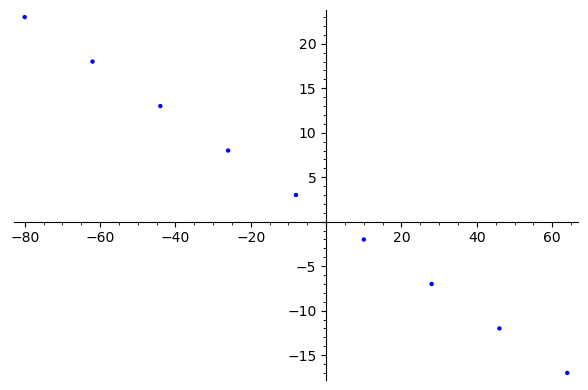

In [318]:
Grafico(10,36,28,80)
